# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Grady Berlik

**Date:** 9/9/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


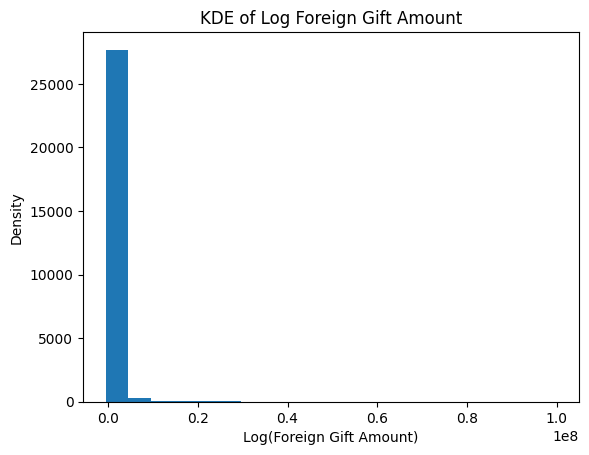

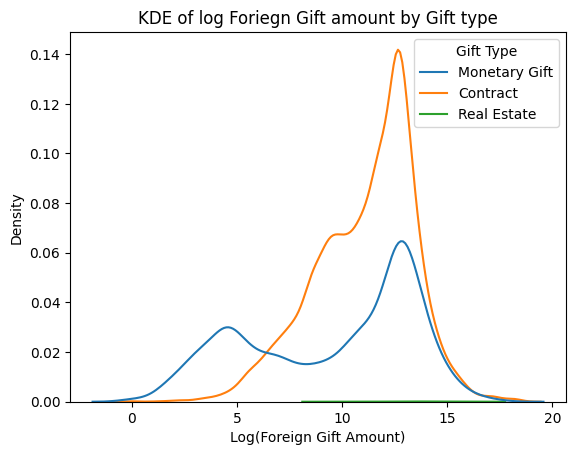

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
ENGLAND 

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('/content/ForeignGifts_edu.csv')
plt.hist(df['Foreign Gift Amount'], bins = 20)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')

#part 2

# raw counts
counts = df['Gift Type'].value_counts()
print(counts)

# as proportions (percentages)
proportions = df['Gift Type'].value_counts(normalize=True)
print(proportions)

#part 3

import seaborn as sns
import numpy as np

# filter out zero/negative amounts (24 rows) before taking log
df_clean = df[df['Foreign Gift Amount'] > 0].copy()
df_clean['log_amount'] = np.log(df_clean['Foreign Gift Amount'])

# overall KDE
sns.kdeplot(df_clean['log_amount'])
plt.xlabel('Log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.title('KDE of Log Foreign Gift Amount')
plt.show()

# conditional KDE by Gift Type
sns.kdeplot(data=df_clean, x='log_amount', hue='Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.title('KDE of log Foriegn Gift amount by Gift type')
plt.show()

# top 15 by number of gifts
by_count = df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)

# top 15 by total dollar amount
by_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

print(by_count)
print(by_amount)

#part 4

# top 15 by number of gifts
by_count = df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)

# top 15 by total dollar amount
by_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

print(by_count)
print(by_amount)

#part 5

by_giftor = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(by_giftor)




Q2 2) It seems like the foreign gift are almost all clustered into a similar range, resulting in an extremely right skewed histogram.
Q2 3) Contracts: 61.2% Monetary gifts: 38.8% Real estate: 0.04%
Q2 4) Contracts cluster tightly around a similar dollar value, while monetary gifts are far more spread out. Monetary gifts also show a noticeably fatter left tail, meaning small-dollar gifts are much more common among monetary gifts than among contracts. Real estate gifts are too few to reveal a reliable pattern, so its near-flat density line isn't very helpful at all.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]